# Introduction

# TCR Diversity — Fig 4D
Number of unique clonotypes and inverse Simpson index for paired pre/on-treatment activated CD8T cells

In [1]:
fig.size <- function(h, w) {
    options(repr.plot.height = h, repr.plot.width = w)
}

In [ ]:
library(data.table)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggrepel)
library(ggthemes)
library(ggpubr)
library(patchwork)
library(Seurat)

Warning message:
“package ‘dplyr’ was built under R version 4.1.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘tidyr’ was built under R version 4.1.3”
Attaching SeuratObject



# Read

In [ ]:
fdir = "tcr/"
cells = fread(file.path(fdir, 'cd8_tcr.csv'))
cells = cells[, .(patientID, cdr3_beta, treatment, response)]

# Overview

In [4]:
cells %>% head()

patientID,cdr3_beta,treatment,response
<chr>,<chr>,<chr>,<chr>
P02,CASSEQDPKIRTTQYF,On,R
P02,CAIRDSGGEQETQYF,On,R
P02,CAIRDSGGEQETQYF,On,R
P02,CAIRDSGGEQETQYF,On,R
P02,CAIRDSGGEQETQYF,On,R
P02,CASSLPQETQYF,On,R


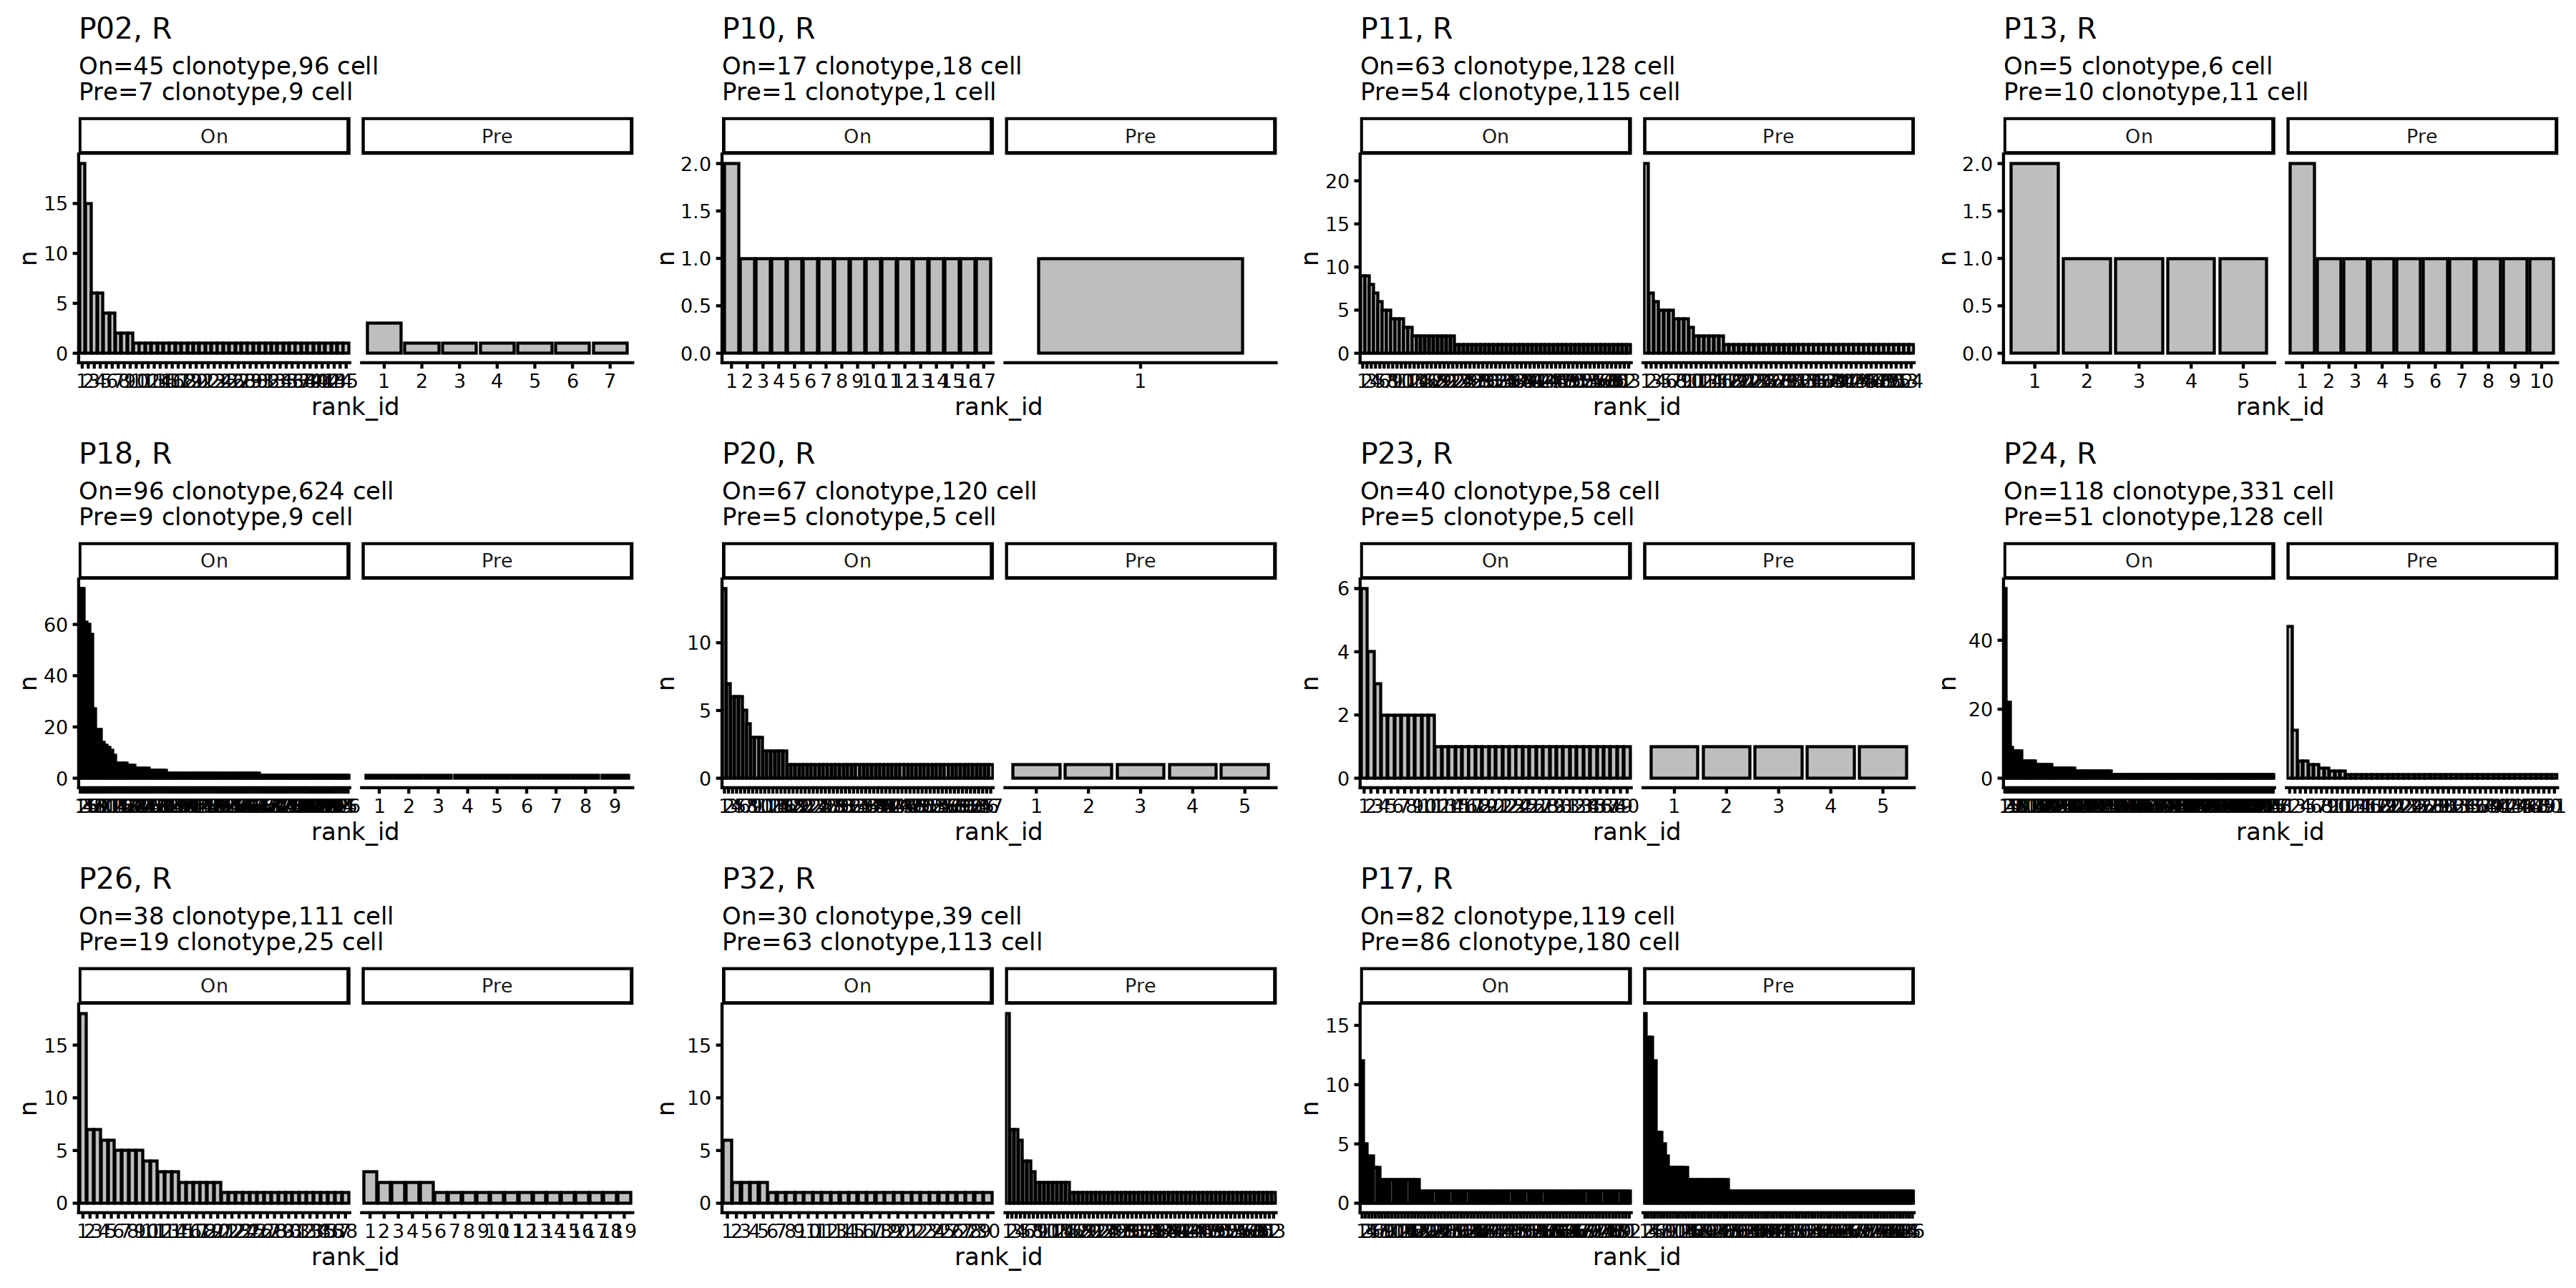

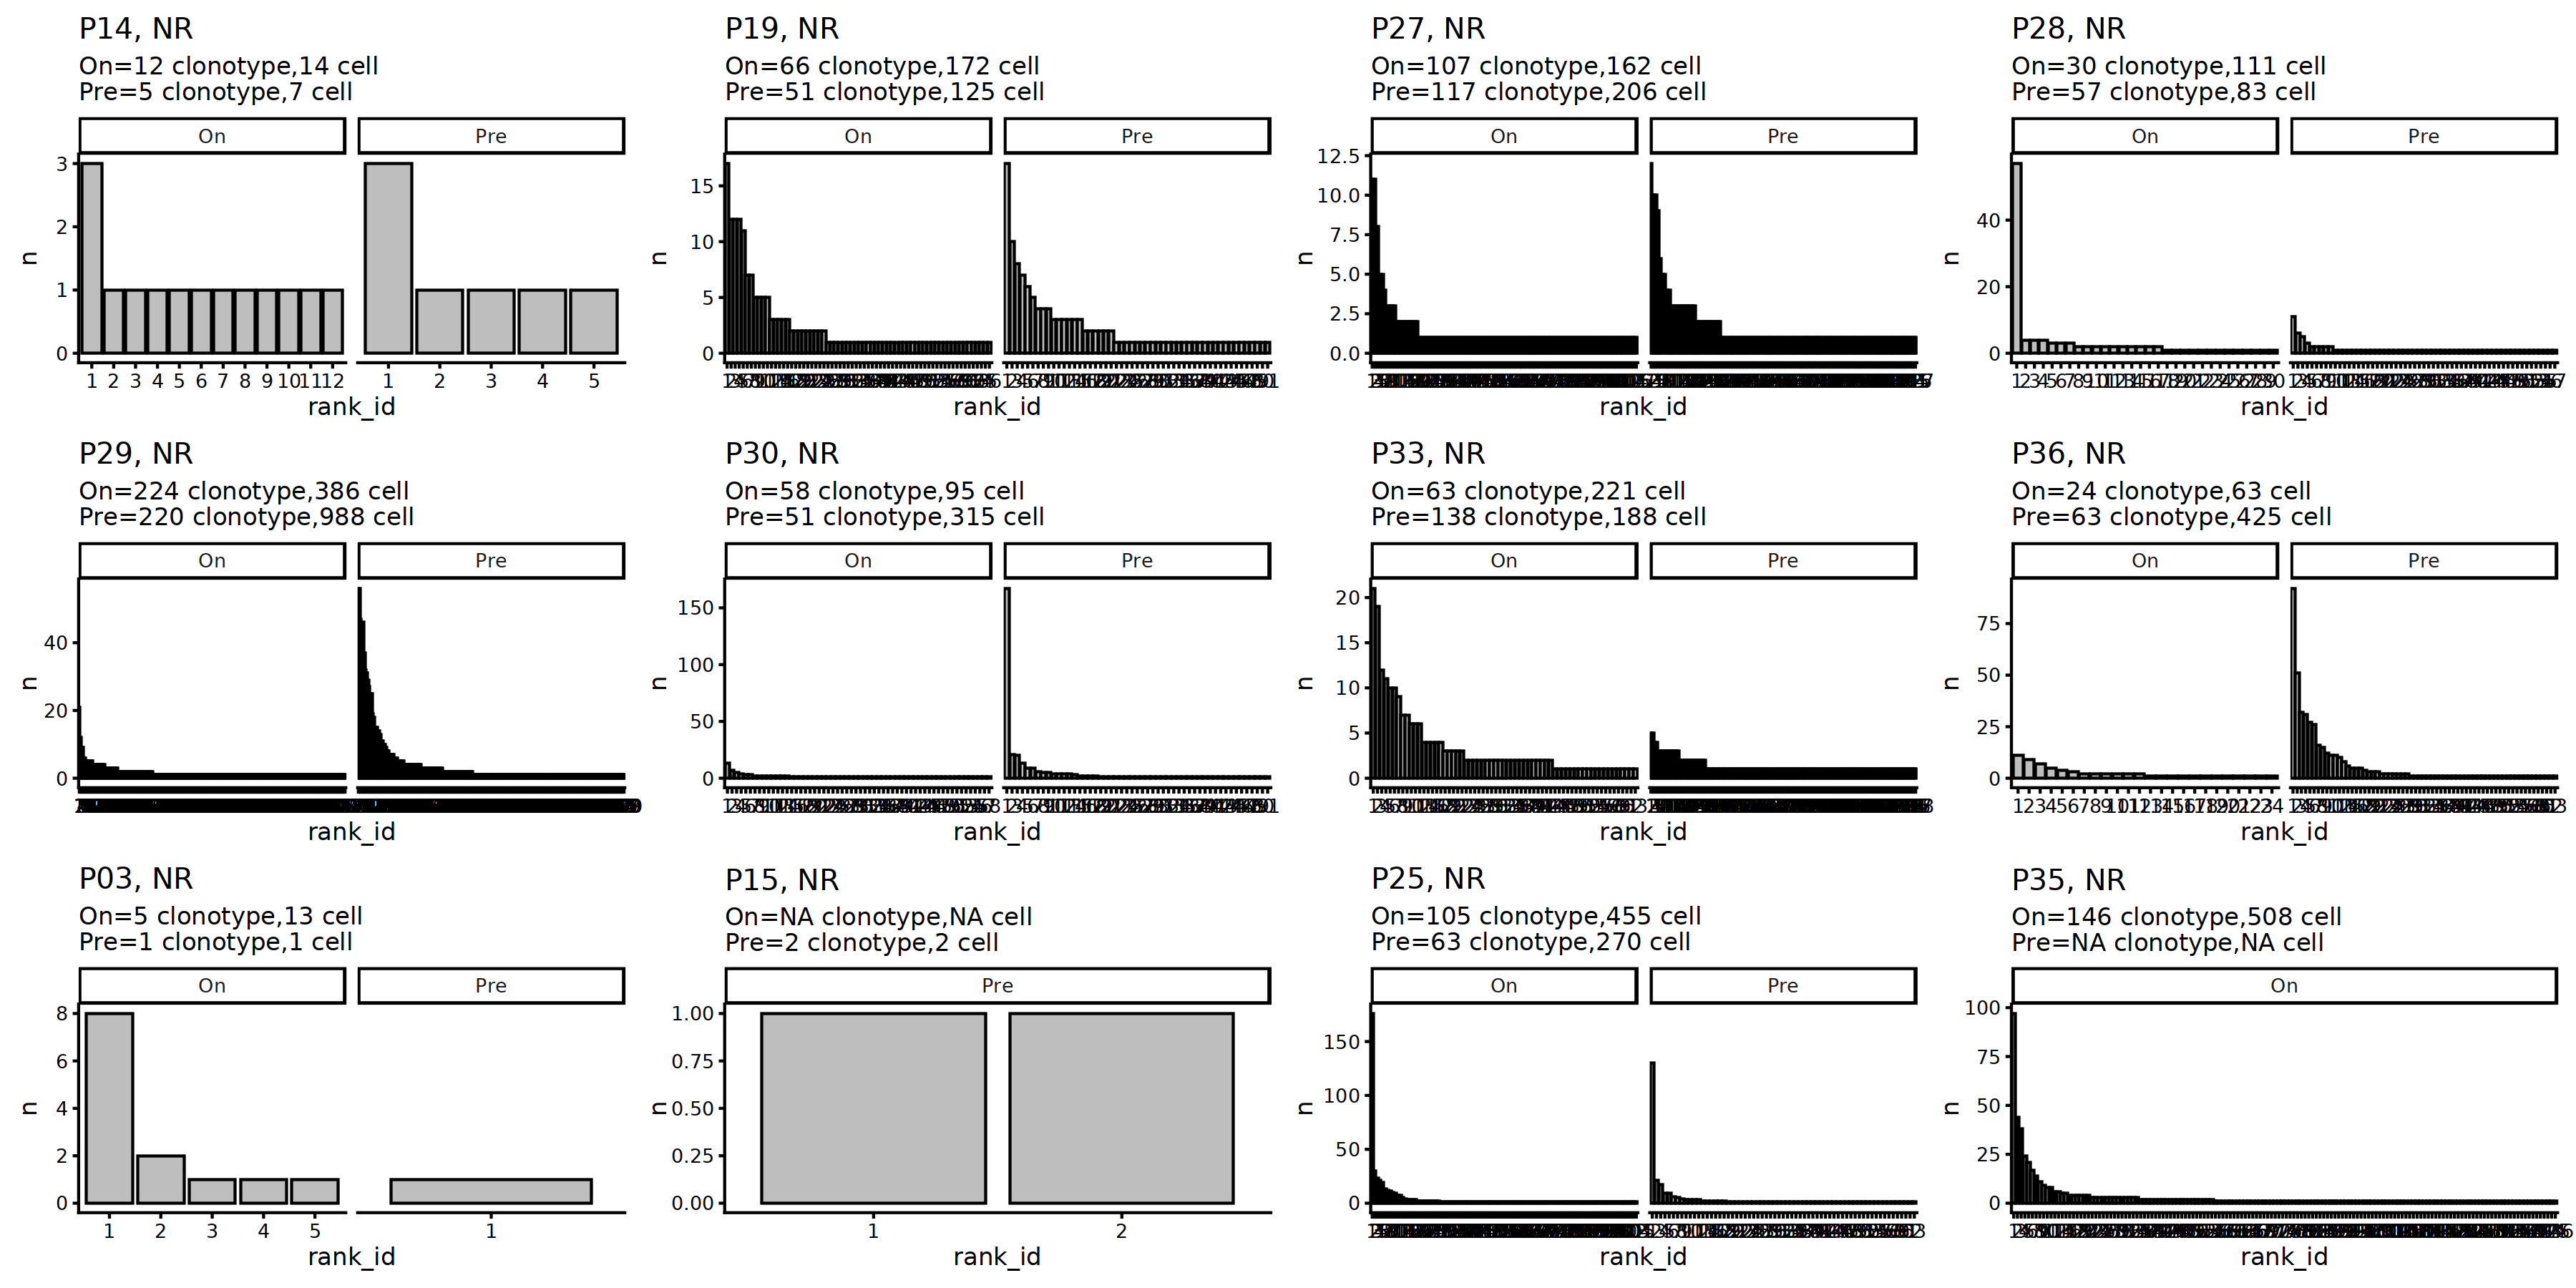

In [5]:
patientID_list <- cells %>% 
    dplyr::select(patientID, response) %>% 
    unique() %>% 
    split(.$response) %>% 
    purrr::map(function(.df).df$patientID)

plist <- cells %>% 
    count(patientID, treatment, response, cdr3_beta) %>% 
    arrange(desc(n)) %>% 
    group_by(patientID, treatment) %>% 
    mutate(rank = row_number()) %>% 
    mutate(rank_id = factor(rank)) %>% 
    ungroup() %>% 
    split(.$patientID) %>% 
    purrr::map(function(.df){
        patientID <- .df[1, "patientID"]
        response <- .df[1, "response"]
        # num_df <- .df %>% 
        #     count(treatment) %>% 
        #     tibble::column_to_rownames("treatment")
        num_df <- .df %>% 
            group_by(treatment) %>% 
            summarise(n_clonotype = n(), n_cell=sum(n)) %>%
            tibble::column_to_rownames("treatment")
        .df %>% 
            ggplot(aes(x = rank_id, y = n)) +
                geom_bar(stat = "identity", color = "black", fill = "gray") +
                facet_wrap(~ treatment, scales = "free_x") +
                theme_classic(base_size = 20) +
                labs(title=paste0(patientID, ", ", response), subtitle=paste0(
                    "On=", num_df["On", "n_clonotype"], " clonotype", ",", 
                    num_df["On", "n_cell"], " cell", "\n",
                    "Pre=", num_df["Pre", "n_clonotype"], " clonotype", ",",
                    num_df["Pre", "n_cell"], " cell")) +
                NULL
    })


fig.size(15, 30)
plist[patientID_list$R] %>% 
    wrap_plots(ncol = 4)
plist[patientID_list$NR] %>% 
    wrap_plots(ncol = 4)

In [6]:
# Number of cells per sample
cells %>% 
    with(table(patientID, treatment))
# Number of clonaltypes per sample
cells %>% 
    unique() %>% 
    with(table(patientID, treatment))

         treatment
patientID  On Pre
      P02  96   9
      P03  13   1
      P10  18   1
      P11 128 115
      P13   6  11
      P14  14   7
      P15   0   2
      P17 119 180
      P18 624   9
      P19 172 125
      P20 120   5
      P23  58   5
      P24 331 128
      P25 455 270
      P26 111  25
      P27 162 206
      P28 111  83
      P29 386 988
      P30  95 315
      P32  39 113
      P33 221 188
      P35 508   0
      P36  63 425

         treatment
patientID  On Pre
      P02  45   7
      P03   5   1
      P10  17   1
      P11  63  54
      P13   5  10
      P14  12   5
      P15   0   2
      P17  82  86
      P18  96   9
      P19  66  51
      P20  67   5
      P23  40   5
      P24 118  51
      P25 105  63
      P26  38  19
      P27 107 117
      P28  30  57
      P29 224 220
      P30  58  51
      P32  30  63
      P33  63 138
      P35 146   0
      P36  24  63

# Number of T/immune cells

In [ ]:
fdir <- file.path("tcr")
sc_t_obj <- readRDS(file.path(fdir, 'obj.RDS'))

In [8]:
sc_t_meta <- sc_t_obj@meta.data

In [9]:
rm(sc_t_obj)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,4142881,221.3,7250235,387.3,7250235,387.3
Vcells,15574255,118.9,751746060,5735.4,806386463,6152.3


In [10]:
sc_t_meta %>% 
    count(category)

category,n
<chr>,<int>
T,134270


In [11]:
t_num_df <- sc_t_meta %>% 
    count(patientID, treatment, response)  %>% 
    rename(n_tcell = n)

In [ ]:
fdir <- file.path(
    "tcr")
all_obj <- readRDS(file = file.path(fdir, 'obj.rds'))

In [13]:
sc_all_meta <- all_obj@meta.data

In [14]:
rm(all_obj)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,4337904,231.7,7250235,387.3,7250235,387.3
Vcells,30233105,230.7,2704897049,20636.8,2850188039,21745.3


In [15]:
sc_all_meta %>% 
    count(category)

category,n
<chr>,<int>
B,16782
Endothelial,9063
Epithelial,95421
Fibroblast,8546
Hepatocytes,5081
Mast,851
Myeloid,43516
Plasma,4343
T,143813


In [16]:
immune_celltypes <- c("B", "Mast", "Myeloid", "Plasma", "T")
immu_num_df <- sc_all_meta %>% 
    filter(category %in% immune_celltypes) %>% 
    count(patientID, treatment, response)  %>% 
    rename(n_immucell = n)

In [17]:
meta <- cells %>% 
    group_by(patientID, treatment, response) %>% 
    mutate(n_cell = n()) %>% 
    ungroup() %>% 
    unique() %>% 
    group_by(patientID, treatment, response) %>% 
    mutate(n_clonaltype = n()) %>% 
    ungroup() %>%
    dplyr::select(!cdr3_beta) %>% 
    unique() %>% 
    left_join(t_num_df) %>% 
    left_join(immu_num_df)

Joining with `by = join_by(patientID, treatment, response)`
Joining with `by = join_by(patientID, treatment, response)`


In [18]:
meta %>% head()

patientID,treatment,response,n_cell,n_clonaltype,n_tcell,n_immucell
<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>
P02,On,R,96,45,1264,1522
P10,On,R,18,17,472,2363
P11,Pre,R,115,54,3186,7697
P11,On,R,128,63,3206,5604
P13,Pre,R,11,10,272,1174
P14,Pre,NR,7,5,86,718


In [19]:
paired_patientID <- meta %>% 
    count(patientID) %>% 
    filter(n == 2) %>% 
    pull(patientID)

# Number of clonotypes 

In [20]:
sample_clonotype <- function(ids, prop, nsample = 5000, .seed = 1, replacement=FALSE){
    set.seed(.seed)
    res_vec <- purrr::map(1:nsample, function(i){
        res <- sample(ids, round(length(ids) * prop), replace = replacement) %>% 
            unique() %>% 
            length()
    }) %>% 
        unlist()
    return(res_vec)
}

clonotype_main <- function(meta_df, cells, scale_var, base_denominator, replacement=FALSE){
    meta_df<- meta_df %>% as.data.frame()
    res <- purrr::map(1:nrow(meta_df), function(i){
            denominator <- meta_df[i, scale_var]
            .patientID <- meta_df[i, "patientID"]
            .treatment <- meta_df[i, "treatment"]
            prop <- base_denominator / denominator
            ids <- cells %>% 
                filter(patientID == .patientID) %>% 
                filter(treatment == .treatment) %>% 
                pull(cdr3_beta)
            res_vec <- sample_clonotype(ids, prop, replacement=replacement)
            res <- list(
                patientID=.patientID, treatment=.treatment, res_vec=res_vec,
                prop=prop, sample_n_cell=length(ids) * prop,
                sample_int=round(length(ids) * prop))
            return(res)
        })
    return(res)
}

In [21]:
system.time({
ds_num <- 500

immu_unqual_patientID <- meta %>% 
    filter(n_immucell < ds_num) %>% 
    pull(patientID) %>% 
    unique()

ds_res <- clonotype_main(
    meta %>% 
        filter(patientID %in% paired_patientID) %>%
        filter(!(patientID %in% immu_unqual_patientID)),
    cells, "n_immucell", ds_num, FALSE)

ds_df <- ds_res %>% 
    purrr::map(function(.res){
        data.frame(
            patientID=.res$patientID, treatment=.res$treatment,
            exp_clonotype=mean(.res$res_vec), sample_n_cell=.res$sample_n_cell,
            sample_int=.res$sample_int)
    }) %>% 
    bind_rows
})

noreplace_500_clonotype_df <- ds_df %>% 
    left_join(meta)

   user  system elapsed 
  2.067   0.064   2.141 

Joining with `by = join_by(patientID, treatment)`


## Plot

$NR
$NR$paired

	Wilcoxon signed rank exact test

data:  .subdf$On and .subdf$Pre
V = 29, p-value = 0.1484
alternative hypothesis: true location shift is not equal to 0


$NR$unpaired

	Wilcoxon rank sum exact test

data:  .subdf$On and .subdf$Pre
W = 36, p-value = 0.7209
alternative hypothesis: true location shift is not equal to 0



$R
$R$paired

	Wilcoxon signed rank exact test

data:  .subdf$On and .subdf$Pre
V = 53, p-value = 0.005859
alternative hypothesis: true location shift is not equal to 0


$R$unpaired

	Wilcoxon rank sum exact test

data:  .subdf$On and .subdf$Pre
W = 79, p-value = 0.02881
alternative hypothesis: true location shift is not equal to 0




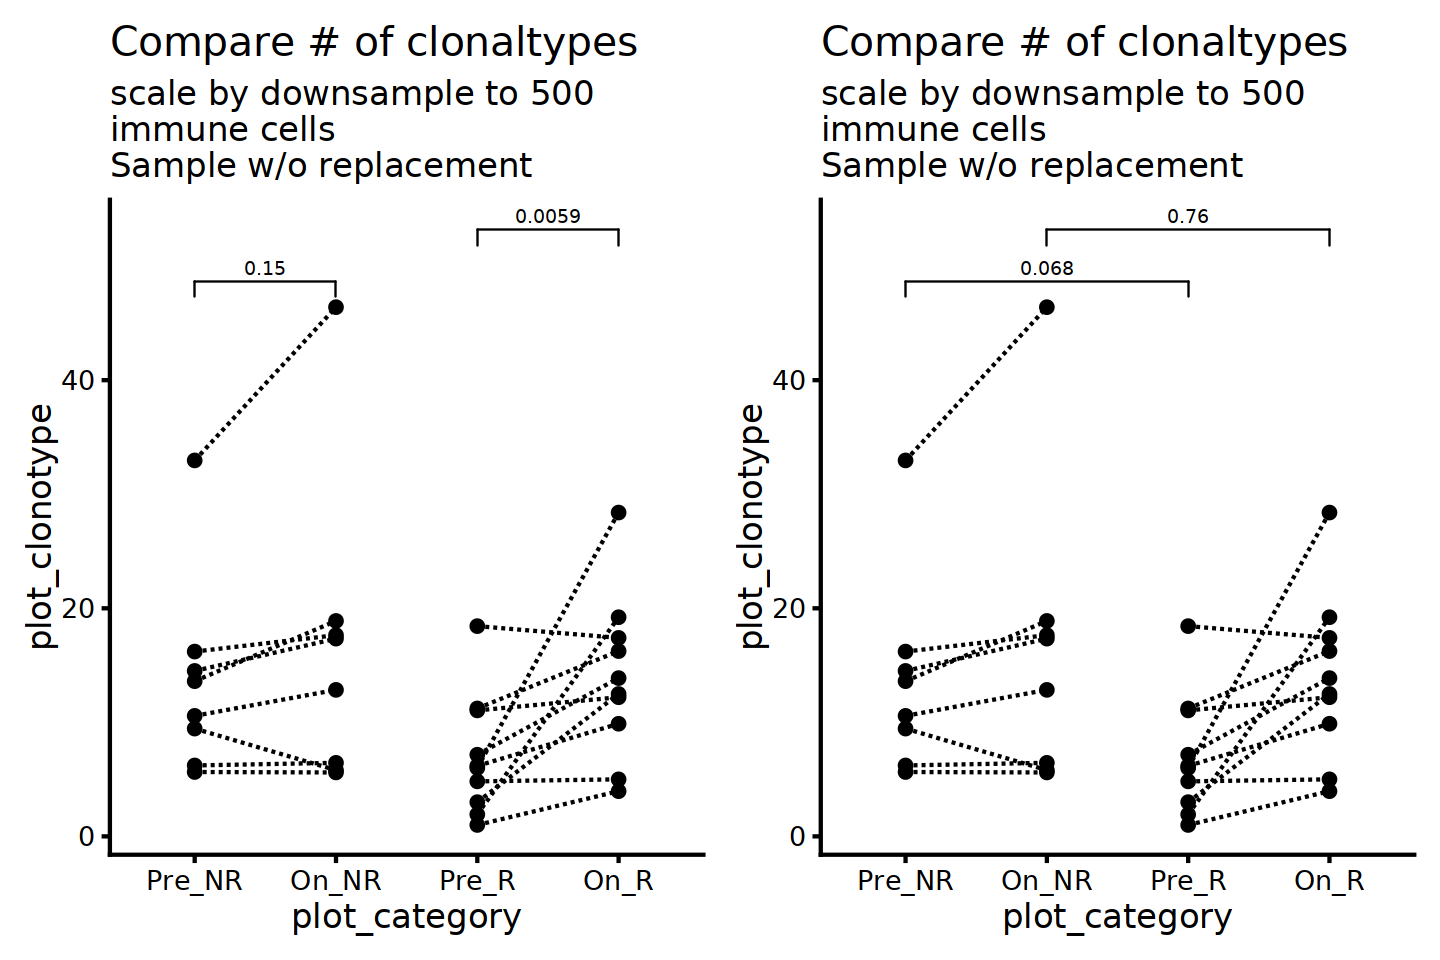

In [22]:
ds_num <- 500
.df <- noreplace_500_clonotype_df %>% 
    filter(patientID %in% paired_patientID)  %>% 
    mutate(plot_category = paste0(treatment, "_", response)) %>% 
    mutate(plot_category = factor(plot_category, levels = c("Pre_NR", "On_NR", "Pre_R", "On_R"))) %>% 
    arrange(patientID, treatment) 

.df <- .df %>% 
    mutate(plot_clonotype = if_else(exp_clonotype==0, 1, exp_clonotype))

p1 <- .df %>% 
    ggplot(aes(x = plot_category, y = plot_clonotype, group = patientID)) +
        geom_point() +
        geom_line(linetype="dashed") +
        geom_signif(
            comparisons = list(c("On_NR", "Pre_NR"), c("On_R", "Pre_R")),
            test = "wilcox.test", step_increase = 0.1, test.args = list(paired = TRUE)) +
        theme_classic(base_size = 20) +
        labs(title = "Compare # of clonaltypes", 
             subtitle = paste0("scale by downsample to ", ds_num, "\n", "immune cells", "\n", "Sample w/o replacement")) +
        NULL

p2 <- .df %>% 
    ggplot(aes(x = plot_category, y = plot_clonotype, group = patientID)) +
        geom_point() +
        geom_line(linetype="dashed") +
        geom_signif(
            comparisons = list(c("Pre_R", "Pre_NR"), c("On_NR", "On_R")),
            test = "wilcox.test", step_increase = 0.1, test.args = list(paired = FALSE)) +
        theme_classic(base_size = 20) +
        labs(title = "Compare # of clonaltypes", 
             subtitle = paste0("scale by downsample to ", ds_num, "\n", "immune cells", "\n", "Sample w/o replacement")) +
        NULL
fig.size(8, 12)
p1 + p2

.df %>% 
    dplyr::select(patientID, treatment, plot_clonotype, response) %>% 
    pivot_wider(values_from = "plot_clonotype", names_from = "treatment") %>% 
    split(~response) %>% 
    purrr::map(function(.subdf){
        res1 <- wilcox.test(.subdf$On, .subdf$Pre, paired = TRUE)
        res2 <- wilcox.test(.subdf$On, .subdf$Pre, paired = FALSE)
        list(paired=res1, unpaired=res2)
    })

In [23]:
# calculate mean or median for patient pairs
.df %>% 
    dplyr::select(patientID, treatment, response, plot_clonotype) %>% 
    pivot_wider(names_from = "treatment", values_from = "plot_clonotype") %>% 
    mutate(fc = On/Pre) %>% 
    group_by(response) %>% 
    mutate(
        mean_fc = mean(fc), median_fc = median(fc),
        geomean_fc = exp(mean(log(fc)))) %>% 
    ungroup() %>% 
    arrange(fc) %>% 
    identity()

patientID,response,On,Pre,fc,mean_fc,median_fc,geomean_fc
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
P27,NR,5.8062,9.4500,0.6144127,1.117496,1.142023,1.087480
P26,R,17.4046,18.4342,0.9441473,3.091701,1.768395,2.279182
P28,NR,5.6044,5.6432,0.9931245,1.117496,1.142023,1.087480
P13,R,5.0000,4.8228,1.0367421,3.091701,1.768395,2.279182
P30,NR,6.4486,6.2188,1.0369525,1.117496,1.142023,1.087480
P19,NR,17.6448,16.2032,1.0889701,1.117496,1.142023,1.087480
P24,R,12.1986,11.0444,1.1045055,3.091701,1.768395,2.279182
P36,NR,17.3372,14.5072,1.1950755,1.117496,1.142023,1.087480
P25,NR,12.8452,10.5666,1.2156417,1.117496,1.142023,1.087480


# invsimpson index

In [24]:
library(vegan)

Warning message:
“package ‘vegan’ was built under R version 4.1.3”
Loading required package: permute

Warning message:
“package ‘permute’ was built under R version 4.1.3”
Loading required package: lattice

Warning message:
“package ‘lattice’ was built under R version 4.1.3”
This is vegan 2.6-4



In [25]:
sample_invsimpson <- function(ids, prop, nsample = 5000, .seed = 1, replacement=FALSE){
    set.seed(.seed)
    res_vec <- purrr::map(1:nsample, function(i){
        res <- sample(ids, round(length(ids) * prop), replace = replacement) %>% 
            table() %>% 
            c() %>% 
            vegan::diversity(index="invsimpson")
        if(is.infinite(res)) {res <- 0} # when sample 0 elements, res would be Inf
        return(res)
    }) %>% 
        unlist()
    return(res_vec)
}

invsimpson_main <- function(meta_df, cells, scale_var, base_denominator, replacement=FALSE){
    meta_df<- meta_df %>% as.data.frame()
    res <- purrr::map(1:nrow(meta_df), function(i){
            denominator <- meta_df[i, scale_var]
            .patientID <- meta_df[i, "patientID"]
            .treatment <- meta_df[i, "treatment"]
            prop <- base_denominator / denominator
            ids <- cells %>% 
                filter(patientID == .patientID) %>% 
                filter(treatment == .treatment) %>% 
                pull(cdr3_beta)
            res_vec <- sample_invsimpson(ids, prop, replacement=replacement)
            res <- list(
                patientID=.patientID, treatment=.treatment, res_vec=res_vec,
                prop=prop, sample_n_cell=length(ids) * prop,
                sample_int=round(length(ids) * prop))
            return(res)
        })
    return(res)
}

In [26]:
system.time({
ds_num <- 500

immu_unqual_patientID <- meta %>% 
    filter(n_immucell < ds_num) %>% 
    pull(patientID) %>% 
    unique()

ds_res <- invsimpson_main(
    meta %>% 
        filter(patientID %in% paired_patientID) %>%
        filter(!(patientID %in% immu_unqual_patientID)),
    cells, "n_immucell", ds_num, FALSE)

ds_df <- ds_res %>% 
    purrr::map(function(.res){
        data.frame(
            patientID=.res$patientID, treatment=.res$treatment,
            exp_invsimpson=mean(.res$res_vec), sample_n_cell=.res$sample_n_cell,
            sample_int=.res$sample_int)
    }) %>% 
    bind_rows()
})

noreplace_500_invsimpson_df <- ds_df %>% 
    left_join(meta)

   user  system elapsed 
 14.606   0.101  14.777 

Joining with `by = join_by(patientID, treatment)`


## Plot

$NR
$NR$paired

	Wilcoxon signed rank exact test

data:  .subdf$On and .subdf$Pre
V = 24, p-value = 0.4609
alternative hypothesis: true location shift is not equal to 0


$NR$unpaired

	Wilcoxon rank sum exact test

data:  .subdf$On and .subdf$Pre
W = 37, p-value = 0.6454
alternative hypothesis: true location shift is not equal to 0



$R
$R$paired

	Wilcoxon signed rank exact test

data:  .subdf$On and .subdf$Pre
V = 51, p-value = 0.01367
alternative hypothesis: true location shift is not equal to 0


$R$unpaired

	Wilcoxon rank sum exact test

data:  .subdf$On and .subdf$Pre
W = 77, p-value = 0.04326
alternative hypothesis: true location shift is not equal to 0




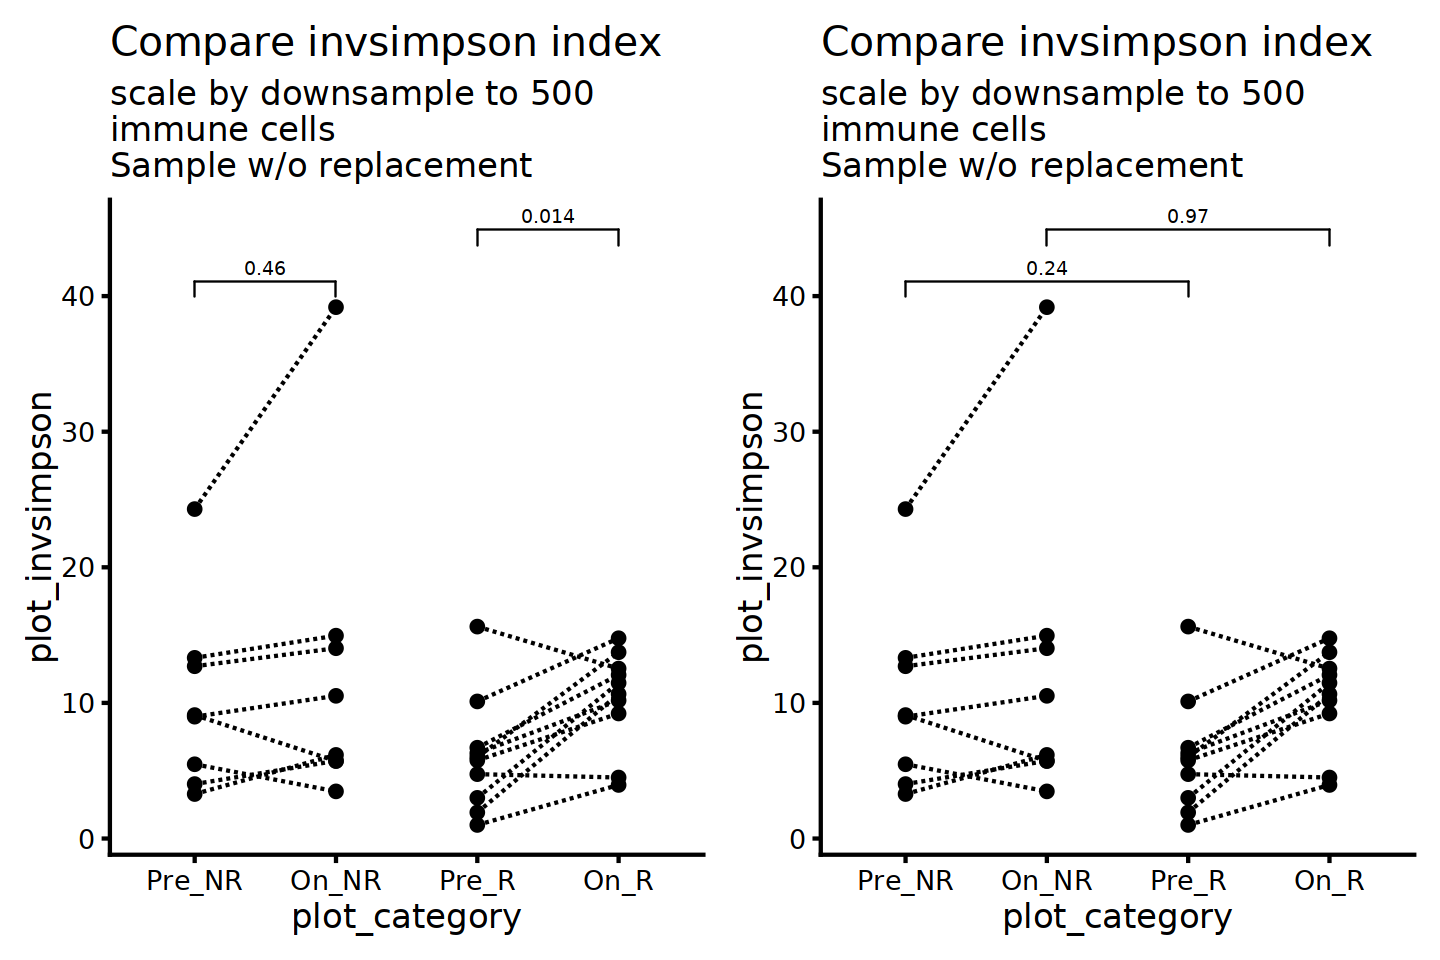

In [27]:
ds_num <- 500
.df <- noreplace_500_invsimpson_df %>% 
    filter(patientID %in% paired_patientID)  %>% 
    mutate(plot_category = paste0(treatment, "_", response)) %>% 
    mutate(plot_category = factor(plot_category, levels = c("Pre_NR", "On_NR", "Pre_R", "On_R"))) %>% 
    arrange(patientID, treatment) 

.df <- .df %>% 
    mutate(plot_invsimpson = if_else(exp_invsimpson==0, 1, exp_invsimpson)) %>% 
    identity()

p1 <- .df %>% 
    ggplot(aes(x = plot_category, y = plot_invsimpson, group = patientID)) +
        geom_point() +
        geom_line(linetype="dashed") +
        geom_signif(
            comparisons = list(c("On_NR", "Pre_NR"), c("On_R", "Pre_R")),
            test = "wilcox.test", step_increase = 0.1, test.args = list(paired = TRUE)) +
        theme_classic(base_size = 20) +
        labs(title = "Compare invsimpson index", 
             subtitle = paste0("scale by downsample to ", ds_num, "\n", "immune cells", "\n", "Sample w/o replacement")) +
        NULL

p2 <- .df %>% 
    ggplot(aes(x = plot_category, y = plot_invsimpson, group = patientID)) +
        geom_point() +
        geom_line(linetype="dashed") +
        geom_signif(
            comparisons = list(c("Pre_R", "Pre_NR"), c("On_NR", "On_R")),
            test = "wilcox.test", step_increase = 0.1, test.args = list(paired = FALSE)) +
        theme_classic(base_size = 20) +
        labs(title = "Compare invsimpson index", 
             subtitle = paste0("scale by downsample to ", ds_num, "\n", "immune cells", "\n", "Sample w/o replacement")) +
        NULL
fig.size(8, 12)
p1 + p2

.df %>% 
    dplyr::select(patientID, treatment, plot_invsimpson, response) %>% 
    pivot_wider(values_from = "plot_invsimpson", names_from = "treatment") %>% 
    split(~response) %>% 
    purrr::map(function(.subdf){
        res1 <- wilcox.test(.subdf$On, .subdf$Pre, paired = TRUE)
        res2 <- wilcox.test(.subdf$On, .subdf$Pre, paired = FALSE)
        list(paired=res1, unpaired=res2)
    })

In [28]:
# calculate mean or median for patient pairs
.df %>% 
    dplyr::select(patientID, treatment, response, plot_invsimpson) %>% 
    pivot_wider(names_from = "treatment", values_from = "plot_invsimpson") %>% 
    mutate(fc = On/Pre) %>% 
    group_by(response) %>% 
    mutate(
        mean_fc = mean(fc), median_fc = median(fc),
        geomean_fc = exp(mean(log(fc)))) %>% 
    ungroup() %>% 
    arrange(fc) %>% 
    identity()

patientID,response,On,Pre,fc,mean_fc,median_fc,geomean_fc
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
P27,NR,5.713000,9.104759,0.6274740,1.197442,1.146894,1.121428
P28,NR,3.476098,5.476517,0.6347279,1.197442,1.146894,1.121428
P26,R,12.534563,15.628384,0.8020383,2.383382,1.710243,1.993808
P13,R,4.500000,4.746857,0.9479957,2.383382,1.710243,1.993808
P19,NR,14.034052,12.704917,1.1046158,1.197442,1.146894,1.121428
P33,NR,14.960171,13.325781,1.1226487,1.197442,1.146894,1.121428
P36,NR,10.523157,8.985404,1.1711390,1.197442,1.146894,1.121428
P25,NR,5.728716,4.016037,1.4264599,1.197442,1.146894,1.121428
P17,R,14.770545,10.110219,1.4609521,2.383382,1.710243,1.993808


In [29]:
sessionInfo()

R version 4.1.2 (2021-11-01)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Red Hat Enterprise Linux 9.7 (Plow)

Matrix products: default
BLAS/LAPACK: /home/hoy821/miniforge3/lib/libopenblasp-r0.3.24.so

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] vegan_2.6-4        lattice_0.21-8     permute_0.9-7      SeuratObject_4.1.4
 [5] Seurat_4.4.0       patchwork_1.3.2    ggpubr_0.6.0       ggthemes_4.2.4    
 [9] ggrepel_0.9.4      ggplot2_4.0.1      tidyr_1.3.0        dplyr_1.1.2       
[13] data.table_1.18.0 

loaded via a namespace (and not